In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from collections import defaultdict
from functools import reduce
import numpy as np
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/2020/"
if os.path.exists(path):
    print("\n📂 Files in the directory:")
    print(os.listdir(path))
else:
    print("\n❌ Directory not found:", path)



📂 Files in the directory:
['preprocessed_lmp_rt_2020Q4.csv', 'preprocessed_gen_2020Q4.csv']


In [5]:

# # Real time price data at frequency of 5 mins across 3 zones
# # Frequency converted to every 10mins to match sunshine data
# lmp_rt_path = "/content/drive/MyDrive/PowerPrices/Data/caiso_lmp_rt_5min_zones_2023Q1.csv"
# pricedata = pd.read_csv(lmp_rt_path, skiprows=3)
# pricedata.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)':'begin_time'}, inplace=True)
# pricedata['begin_time'] = pd.to_datetime(pricedata['begin_time'])
# pricedata = pricedata[pricedata['begin_time'].apply(lambda x: x.minute % 10 == 0)]

# # Electricity generation data by source type at frequency of 5 mins
# # Frequency converted to every 10mins to match sunshine data
# gen_path = "/content/drive/MyDrive/PowerPrices/Data/caiso_gen_all_5min_2023Q1.csv"
# gendata = pd.read_csv(gen_path, skiprows=3)
# gendata.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)':'begin_time'}, inplace=True)
# gendata['begin_time'] = pd.to_datetime(gendata['begin_time'])
# gendata = gendata[gendata['begin_time'].apply(lambda x: x.minute % 10 == 0)]
# gendata['solar_scaled'] = gendata.apply(lambda x: x['Solar Generation (MW)']/20 , axis=1)
# gendata = gendata[gendata.apply(lambda x : x['solar_scaled']>0, axis=1)]



In [16]:
# # Only run if you need to create your own copy of preprocessed lmp data. Else use the saved output of this code.
# def preprocess_power_data(year, quarter):
#     """
#     Preprocesses power price and generation data for a given year and quarter.

#     Parameters:
#         year (int): The year (e.g., 2023).
#         quarter (str): The quarter in 'QX' format (e.g., 'Q1').

#     Returns:
#         tuple: Processed price and generation DataFrames or (None, None) if files are missing.
#     """
#     # Correct LMP file path (for zones)
#     lmp_rt_path = f"/content/drive/MyDrive/PowerPrices/Data/rt_lmp_data/{year}/caiso_lmp_rt_5min_zones_{year}{quarter}.csv"
#     gen_path = f"/content/drive/MyDrive/PowerPrices/Data/gen_data/{year}/caiso_gen_all_5min_{year}{quarter}.csv"

#     # Preprocessed output folder
#     output_dir = f"/content/drive/MyDrive/PowerPrices/Data/preprocessed/{year}/"
#     os.makedirs(output_dir, exist_ok=True)  # Ensure directory exists

#     # Debugging: Print file paths to verify correctness
#     print(f"Checking files:\n  {lmp_rt_path}\n  {gen_path}")

#     # Check if files exist
#     if not os.path.exists(lmp_rt_path):
#         print(f"Error: Price data file not found: {lmp_rt_path}")
#         return None, None
#     if not os.path.exists(gen_path):
#         print(f"Error: Generation data file not found: {gen_path}")
#         return None, None

#     # Load and preprocess price data
#     pricedata = pd.read_csv(lmp_rt_path, skiprows=3)
#     pricedata.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
#     pricedata['begin_time'] = pd.to_datetime(pricedata['begin_time'])
#     pricedata = pricedata[pricedata['begin_time'].dt.minute % 10 == 0]  # Filter to 10-minute intervals

#     # Save preprocessed price data
#     price_output_path = os.path.join(output_dir, f"preprocessed_lmp_rt_{year}{quarter}.csv")
#     pricedata.to_csv(price_output_path, index=False)
#     print(f"✅ Saved: {price_output_path}")

#     # Load and preprocess generation data
#     gendata = pd.read_csv(gen_path, skiprows=3)
#     gendata.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
#     gendata['begin_time'] = pd.to_datetime(gendata['begin_time'])
#     gendata = gendata[gendata['begin_time'].dt.minute % 10 == 0]  # Filter to 10-minute intervals
#     gendata['solar_scaled'] = gendata['Solar Generation (MW)'] / 20
#     gendata = gendata[gendata['solar_scaled'] > 0]  # Keep only positive solar generation

#     # Save preprocessed generation data
#     gen_output_path = os.path.join(output_dir, f"preprocessed_gen_{year}{quarter}.csv")
#     gendata.to_csv(gen_output_path, index=False)
#     print(f"✅ Saved: {gen_output_path}")

#     return pricedata, gendata

# # Process all years from 2020Q4 to 2025Q1
# years = range(2020, 2026)
# quarters = ["Q1", "Q2", "Q3", "Q4"]

# for year in years:
#     for quarter in quarters:
#         quarter_str = f"{year}{quarter}"
#         if quarter_str < "2020Q4" or quarter_str > "2025Q1":  # Skip out-of-range quarters
#             continue
#         print(f"\nProcessing {quarter_str}...")
#         preprocess_power_data(year, quarter)

# print("\n✅ All data from 2020Q4 to 2025Q1 successfully processed and saved!")



Processing 2020Q4...
Checking files:
  /content/drive/MyDrive/PowerPrices/Data/rt_lmp_data/2020/caiso_lmp_rt_5min_zones_2020Q4.csv
  /content/drive/MyDrive/PowerPrices/Data/gen_data/2020/caiso_gen_all_5min_2020Q4.csv
✅ Saved: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2020/preprocessed_lmp_rt_2020Q4.csv
✅ Saved: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2020/preprocessed_gen_2020Q4.csv

Processing 2021Q1...
Checking files:
  /content/drive/MyDrive/PowerPrices/Data/rt_lmp_data/2021/caiso_lmp_rt_5min_zones_2021Q1.csv
  /content/drive/MyDrive/PowerPrices/Data/gen_data/2021/caiso_gen_all_5min_2021Q1.csv
✅ Saved: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_lmp_rt_2021Q1.csv
✅ Saved: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_gen_2021Q1.csv

Processing 2021Q2...
Checking files:
  /content/drive/MyDrive/PowerPrices/Data/rt_lmp_data/2021/caiso_lmp_rt_5min_zones_2021Q2.csv
  /content/drive/MyDrive/PowerPrices/Data/gen_

In [17]:
# Load the preprocessed LMP data for 2020 Q4
file_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/2020/preprocessed_lmp_rt_2020Q4.csv"

# Read and display the first few rows
pricedata_2020Q4 = pd.read_csv(file_path)
display(pricedata_2020Q4.head())  # Display the first 5 rows


,UTC Timestamp (Interval Ending),begin_time,Local Timestamp Pacific Time (Interval Ending),Local Date,Hour Number,NP-15 LMP,SP-15 LMP,ZP-26 LMP,NP-15 (Congestion),SP-15 (Congestion),ZP-26 (Congestion),NP-15 (Energy),SP-15 (Energy),ZP-26 (Energy),NP-15 (Loss),SP-15 (Loss),ZP-26 (Loss)
0,2020-10-01 07:05:00,2020-10-01 00:00:00,2020-10-01 00:05:00,2020-10-01,1,27.36302,27.31358,NaN,0.0,0.0,NaN,27.46739,27.46739,NaN,-0.10438,-0.15382,NaN
1,2020-10-01 07:15:00,2020-10-01 00:10:00,2020-10-01 00:15:00,2020-10-01,1,30.90789,30.85204,NaN,0.0,0.0,NaN,31.02579,31.02579,NaN,-0.11790,-0.17374,NaN
2,2020-10-01 07:25:00,2020-10-01 00:20:00,2020-10-01 00:25:00,2020-10-01,1,31.80457,31.43390,NaN,0.0,0.0,NaN,31.68101,31.68101,NaN,0.12356,-0.24711,NaN
3,2020-10-01 07:35:00,2020-10-01 00:30:00,2020-10-01 00:35:00,2020-10-01,1,30.27692,29.90872,NaN,0.0,0.0,NaN,30.18034,30.18034,NaN,0.09658,-0.27162,NaN
4,2020-10-01 07:45:00,2020-10-01 00:40:00,2020-10-01 00:45:00,2020-10-01,1,30.64798,30.27526,NaN,0.0,0.0,NaN,30.55022,30.55022,NaN,0.09776,-0.27495,NaN


In [8]:
# Define the base directory for preprocessed generation data
base_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/"

# Define the range of years and quarters
years = range(2020, 2026)  # Covers 2020 to 2025
quarters = ["Q1", "Q2", "Q3", "Q4"]

# Initialize a list to store processed dataframes
gen_data_list = []

# Loop through each year and quarter to process preprocessed generation data
for year in years:
    for quarter in quarters:
        quarter_str = f"{year}{quarter}"
        if quarter_str < "2020Q4" or quarter_str > "2025Q1":  # Skip out-of-range quarters
            continue

        # Construct the correct file path
        file_path = f"/content/drive/MyDrive/PowerPrices/Data/preprocessed/{year}/preprocessed_gen_{year}{quarter}.csv"

        # Check if file exists before loading
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)

            # Create the new column: Fraction of power coming from solar during the day
            df["Fraction of power from solar during the day"] = df["Solar Generation (MW)"] / df["Total Generation (MW)"]

            # Add a quarter column for tracking
            df["quarter"] = quarter_str

            # Append the processed dataframe
            gen_data_list.append(df)
            print(f"✅ Processed: {file_path}")
        else:
            print(f"❌ Missing file: {file_path}")

# Concatenate all available generation dataframes into a single dataframe
if gen_data_list:
    stacked_gen_data = pd.concat(gen_data_list, ignore_index=True)

    # Define the output path for the processed generation data
    output_file_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_generation_data_with_solar_fraction.csv"

    # Save the processed dataframe as a CSV file
    stacked_gen_data.to_csv(output_file_path, index=False)
    print(f"✅ Processed Generation Data saved to: {output_file_path}")

else:
    print("❌ No generation data files were found. Please check the directory.")


✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2020/preprocessed_gen_2020Q4.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_gen_2021Q1.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_gen_2021Q2.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_gen_2021Q3.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_gen_2021Q4.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_gen_2022Q1.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_gen_2022Q2.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_gen_2022Q3.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_gen_2022Q4.csv
✅ Processed: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2023/preprocessed_gen_2023Q1.csv
✅ Processe

In [9]:
# Look at stacked gen data
stacked_gen_data_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_generation_data_with_solar_fraction.csv"
stacked_gen_data = pd.read_csv(stacked_gen_data_path)
stacked_gen_data.head()

,UTC Timestamp (Interval Ending),begin_time,Local Timestamp Pacific Time (Interval Ending),Local Date,Hour Number,Total Generation (MW),Batteries Generation (MW),Biogas Generation (MW),Biomass Generation (MW),Coal Generation (MW),...,Large Hydro Generation (MW),Natural Gas Generation (MW),Nuclear Generation (MW),Other Generation (MW),Small Hydro Generation (MW),Solar Generation (MW),Wind Generation (MW),solar_scaled,Fraction of power from solar during the day,quarter
0,2020-10-01 13:55:00,2020-10-01 06:50:00,2020-10-01 06:55:00,2020-10-01,7,25990.0,-5.0,199.0,364.0,11.0,...,1268.0,10394.0,2106.0,0.0,205.0,26.0,253.0,1.30,0.001000,2020Q4
1,2020-10-01 14:05:00,2020-10-01 07:00:00,2020-10-01 07:05:00,2020-10-01,8,26096.0,-2.0,199.0,366.0,12.0,...,1279.0,10618.0,2106.0,0.0,163.0,189.0,246.0,9.45,0.007242,2020Q4
2,2020-10-01 14:15:00,2020-10-01 07:10:00,2020-10-01 07:15:00,2020-10-01,8,26422.0,0.0,199.0,366.0,12.0,...,1253.0,10731.0,2106.0,0.0,162.0,509.0,234.0,25.45,0.019264,2020Q4
3,2020-10-01 14:25:00,2020-10-01 07:20:00,2020-10-01 07:25:00,2020-10-01,8,26637.0,-2.0,200.0,369.0,12.0,...,1179.0,10787.0,2106.0,0.0,161.0,969.0,213.0,48.45,0.036378,2020Q4
4,2020-10-01 14:35:00,2020-10-01 07:30:00,2020-10-01 07:35:00,2020-10-01,8,26750.0,-8.0,198.0,367.0,11.0,...,1166.0,10584.0,2107.0,0.0,160.0,1614.0,189.0,80.70,0.060336,2020Q4


In [4]:
# Define the base directory
base_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/"

# Define the range of years and quarters
years = range(2020, 2026)  # Covers 2020 to 2025
quarters = ["Q1", "Q2", "Q3", "Q4"]

# Initialize a list to store dataframes
price_data_list = []

# Loop through each year and quarter to load and append preprocessed LMP data
for year in years:
    for quarter in quarters:
        quarter_str = f"{year}{quarter}"
        if quarter_str < "2020Q4" or quarter_str > "2025Q1":  # Skip out-of-range quarters
            continue

        # Construct the correct file path
        file_path = f"/content/drive/MyDrive/PowerPrices/Data/preprocessed/{year}/preprocessed_lmp_rt_{year}{quarter}.csv"

        # Load the file
        df = pd.read_csv(file_path)
        df["quarter"] = quarter_str  # Add a column to identify the quarter
        price_data_list.append(df)
        print(f"✅ Loaded: {file_path}")

# Concatenate all LMP price dataframes into a single dataframe
stacked_lmp_data = pd.concat(price_data_list, ignore_index=True)

# Define the output path for the stacked LMP data
output_file_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_lmp_price_data.csv"

# Save the stacked dataframe as a CSV file
stacked_lmp_data.to_csv(output_file_path, index=False)
print(f"✅ Stacked LMP price data saved to: {output_file_path}")

# # Display the stacked dataframe
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Stacked LMP Price Data", dataframe=stacked_lmp_data)


✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2020/preprocessed_lmp_rt_2020Q4.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_lmp_rt_2021Q1.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_lmp_rt_2021Q2.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_lmp_rt_2021Q3.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2021/preprocessed_lmp_rt_2021Q4.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_lmp_rt_2022Q1.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_lmp_rt_2022Q2.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_lmp_rt_2022Q3.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2022/preprocessed_lmp_rt_2022Q4.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/preprocessed/2023/preprocessed_lmp_rt_2023Q1.csv
✅ Loaded: 

ModuleNotFoundError: No module named 'ace_tools'

In [6]:
# View stacked lmp data
stacked_lmp_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_lmp_price_data.csv"
stacked_lmp_data = pd.read_csv(stacked_lmp_path)
stacked_lmp_data.head()

,UTC Timestamp (Interval Ending),begin_time,Local Timestamp Pacific Time (Interval Ending),Local Date,Hour Number,NP-15 LMP,SP-15 LMP,ZP-26 LMP,NP-15 (Congestion),SP-15 (Congestion),ZP-26 (Congestion),NP-15 (Energy),SP-15 (Energy),ZP-26 (Energy),NP-15 (Loss),SP-15 (Loss),ZP-26 (Loss),quarter
0,2020-10-01 07:05:00,2020-10-01 00:00:00,2020-10-01 00:05:00,2020-10-01,1,27.36302,27.31358,NaN,0.0,0.0,NaN,27.46739,27.46739,NaN,-0.10438,-0.15382,NaN,2020Q4
1,2020-10-01 07:15:00,2020-10-01 00:10:00,2020-10-01 00:15:00,2020-10-01,1,30.90789,30.85204,NaN,0.0,0.0,NaN,31.02579,31.02579,NaN,-0.11790,-0.17374,NaN,2020Q4
2,2020-10-01 07:25:00,2020-10-01 00:20:00,2020-10-01 00:25:00,2020-10-01,1,31.80457,31.43390,NaN,0.0,0.0,NaN,31.68101,31.68101,NaN,0.12356,-0.24711,NaN,2020Q4
3,2020-10-01 07:35:00,2020-10-01 00:30:00,2020-10-01 00:35:00,2020-10-01,1,30.27692,29.90872,NaN,0.0,0.0,NaN,30.18034,30.18034,NaN,0.09658,-0.27162,NaN,2020Q4
4,2020-10-01 07:45:00,2020-10-01 00:40:00,2020-10-01 00:45:00,2020-10-01,1,30.64798,30.27526,NaN,0.0,0.0,NaN,30.55022,30.55022,NaN,0.09776,-0.27495,NaN,2020Q4


In [13]:
print(f"length of stacked lmp_data: {len(stacked_lmp_data)}")
print(f"length of stacked gen_data: {len(stacked_gen_data)}")

length of stacked lmp_data: 218861
length of stacked gen_data: 131263


There is a mismatch in length which indicates the data collection has started at different time points for each day. One can verify by looking at the first row of both datasets above.

In [9]:
file_path = "/content/drive/MyDrive/PowerPrices/Data/Load_Forecast/caiso_load-temp_hr_2021.csv"

df = pd.read_csv(file_path, skiprows = 3)
df.head()



,UTC Timestamp (Interval Ending),Local Timestamp Pacific Time (Interval Beginning),Local Timestamp Pacific Time (Interval Ending),Local Date,Hour Number,CAISO Total Actual Load (MW),CAISO Total Forecast Load (MW),Actual Load (MW),Arizona Public Service Company Actual Load (MW),BANC/SMUD Actual Load (MW),...,Southern California Edison Forecast Load (MW),The Metropolitan Water District of Southern California Forecast Load (MW),Turlock Irrigation District Forecast Load (MW),Valley Electric Association Forecast Load (MW),Los Angeles Temperature (Fahrenheit),Los Angeles Temperature Observation Time (Pacific),Sacramento / Metro Temperature (Fahrenheit),Sacramento / Metro Temperature Observation Time (Pacific),San Jose Temperature (Fahrenheit),San Jose Temperature Observation Time (Pacific)
0,2021-03-12 09:00:00,2021-03-12 00:00:00,2021-03-12 01:00:00,2021-03-12,1,NaN,22044.79,NaN,NaN,NaN,...,9686.47,198.85,NaN,73.56,46.9,2021-03-12 00:53:00,42.1,2021-03-12 00:53:00,41.0,2021-03-12 00:53:00
1,2021-03-12 10:00:00,2021-03-12 01:00:00,2021-03-12 02:00:00,2021-03-12,2,NaN,21528.99,NaN,NaN,NaN,...,9474.64,200.28,NaN,75.45,46.9,2021-03-12 01:53:00,41.0,2021-03-12 01:53:00,42.1,2021-03-12 01:53:00
2,2021-03-12 11:00:00,2021-03-12 02:00:00,2021-03-12 03:00:00,2021-03-12,3,NaN,21185.58,NaN,NaN,NaN,...,9339.19,199.19,NaN,77.54,46.0,2021-03-12 02:53:00,42.1,2021-03-12 02:53:00,39.9,2021-03-12 02:53:00
3,2021-03-12 12:00:00,2021-03-12 03:00:00,2021-03-12 04:00:00,2021-03-12,4,NaN,21152.22,NaN,NaN,NaN,...,9304.25,199.28,NaN,81.10,45.0,2021-03-12 03:53:00,41.0,2021-03-12 03:53:00,39.9,2021-03-12 03:53:00
4,2021-03-12 13:00:00,2021-03-12 04:00:00,2021-03-12 05:00:00,2021-03-12,5,NaN,21712.38,NaN,NaN,NaN,...,9545.95,200.19,NaN,86.67,44.1,2021-03-12 04:53:00,39.9,2021-03-12 04:53:00,39.9,2021-03-12 04:53:00


In [11]:
# Define the base directory for Load Forecast data
base_path = "/content/drive/MyDrive/PowerPrices/Data/Load_Forecast/"

# Define available years
years = [2021, 2022, 2023, 2024, 2025]

# Initialize a list to store dataframes
load_forecast_data_list = []

# Loop through each year and process data
for year in years:
    file_path = os.path.join(base_path, f"caiso_load-temp_hr_{year}.csv")

    if os.path.exists(file_path):  # Check if file exists before loading
        df = pd.read_csv(file_path, skiprows=3, delimiter=",")
        df["year"] = year  # Add a year column
        load_forecast_data_list.append(df)
        print(f"✅ Loaded: {file_path}")
    else:
        print(f"❌ Missing file: {file_path}")

# Concatenate all available Load Forecast data
if load_forecast_data_list:
    stacked_load_forecast_data = pd.concat(load_forecast_data_list, ignore_index=True)

    # Save the stacked dataset
    output_file_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_load_forecast_data.csv"
    stacked_load_forecast_data.to_csv(output_file_path, index=False)
    print(f"✅ Stacked Load Forecast data saved to: {output_file_path}")

else:
    print("❌ No files were found. Please check the directory.")


✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/Load_Forecast/caiso_load-temp_hr_2021.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/Load_Forecast/caiso_load-temp_hr_2022.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/Load_Forecast/caiso_load-temp_hr_2023.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/Load_Forecast/caiso_load-temp_hr_2024.csv
✅ Loaded: /content/drive/MyDrive/PowerPrices/Data/Load_Forecast/caiso_load-temp_hr_2025.csv
✅ Stacked Load Forecast data saved to: /content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_load_forecast_data.csv


In [15]:
# Load stacked load forecast data
stacked_load_forecast_path = "/content/drive/MyDrive/PowerPrices/Data/preprocessed/stacked_load_forecast_data.csv"
stacked_load_forecast_data = pd.read_csv(stacked_load_forecast_path)
# 1st row
stacked_load_forecast_data['Southern California Edison Forecast Load (MW)']

,Southern California Edison Forecast Load (MW)
0,9686.47
1,9474.64
2,9339.19
3,9304.25
4,9545.95
...,...
33620,10324.57
33621,10374.19
33622,10306.88
33623,10045.05


In [8]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

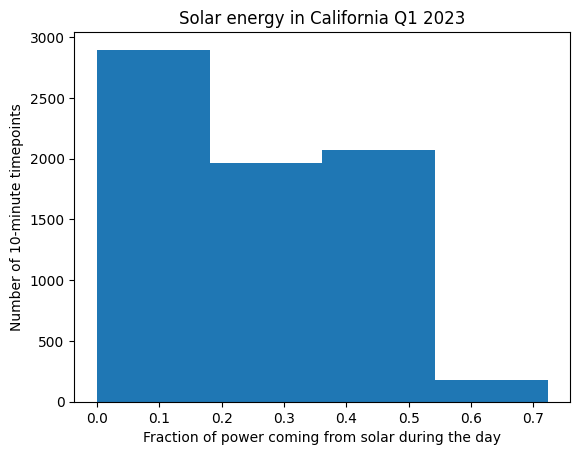

In [9]:
plt.hist((gendata['Solar Generation (MW)']/gendata['Total Generation (MW)']).values, 4)
plt.xlabel('Fraction of power coming from solar during the day')
plt.ylabel('Number of 10-minute timepoints')
plt.title('Solar energy in California Q1 2023')
plt.show()

In [10]:
#Combine solar generation and prices dataframes

solar_gendata = gendata[['begin_time', 'solar_scaled']]
pricedata = pricedata[['begin_time', 'NP-15 LMP', 'SP-15 LMP', 'ZP-26 LMP']]
solargen_price_combined = solar_gendata.merge(pricedata, on='begin_time')

#Get daily averages

avgs_price = solargen_price_combined.groupby(solargen_price_combined['begin_time'].apply(lambda x: x.date()), sort=False)[['solar_scaled', 'NP-15 LMP', 'SP-15 LMP', 'ZP-26 LMP']].mean()

avgs_price

,solar_scaled,NP-15 LMP,SP-15 LMP,ZP-26 LMP
begin_time,,,,
2023-01-01,199.658824,107.210852,105.966267,104.711250
2023-01-02,162.255422,195.451478,184.458411,185.637342
2023-01-03,308.621186,159.236077,155.803726,157.307438
2023-01-04,174.082759,166.378159,159.711481,168.384469
2023-01-05,187.877500,160.893754,157.077931,158.596737
...,...,...,...,...
2023-03-27,401.908553,23.201620,18.843777,17.535119
2023-03-28,377.618125,91.155882,34.375740,41.334702
2023-03-29,333.537662,82.856860,63.176105,57.289178


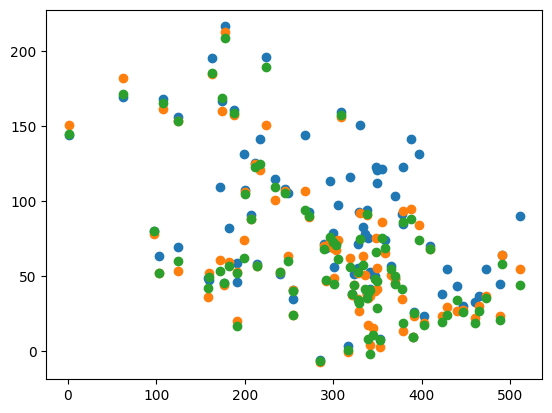

In [11]:


#Plot solar generation vs prices

plt.scatter(avgs_price['solar_scaled'], avgs_price['NP-15 LMP'])
plt.scatter(avgs_price['solar_scaled'], avgs_price['SP-15 LMP'])
plt.scatter(avgs_price['solar_scaled'], avgs_price['ZP-26 LMP'])

plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(avgs_price['solar_scaled'].values.reshape(-1,1), avgs_price['NP-15 LMP'].values)

linreg.coef_

array([-0.19019823])

In [ ]:
places = ['imperial', 'kern', 'kings', 'riverside', 'san_bernardino']
data_by_places = defaultdict(lambda: pd.DataFrame())

for place in places:
    data_by_places[place] = pd.read_csv('Data/'+place+'.csv', skiprows = 2)
    data_by_places[place]['begin_time'] = data_by_places[place].apply(lambda x: datetime.datetime(int(x['Year']), int(x['Month']), int(x['Day']), int(x['Hour']), int(x['Minute']),0) , axis=1)

weather_attributes = ['DNI'] #Incomplete for now

data_by_attributes = {'DNI': pd.DataFrame()}

for item in weather_attributes:
    dfs_to_merge=[]
    for place in places:
        dfs_to_merge.append((place, data_by_places[place][['begin_time', item]][data_by_places[place].apply(lambda x: x[item]>0, axis=1)]))
    initialcolumn = item+'_'+places[0]
    data_by_attributes[item] = reduce(lambda x, y: ('', pd.merge(x[1], y[1], on='begin_time', how='inner', suffixes=(None, '_'+y[0]))),  dfs_to_merge)[1].rename(columns={item:initialcolumn})

data_by_attributes['DNI']

,begin_time,DNI_imperial,DNI_kern,DNI_kings,DNI_riverside,DNI_san_bernardino
0,2023-01-02 07:50:00,33,2,1,2,2
1,2023-01-02 08:00:00,41,4,2,3,3
2,2023-01-02 08:10:00,41,5,3,4,3
3,2023-01-02 08:20:00,43,7,4,4,3
4,2023-01-02 08:30:00,43,9,4,5,4
...,...,...,...,...,...,...
20004,2023-12-31 14:00:00,409,5,249,83,231
20005,2023-12-31 14:10:00,441,6,99,87,95
20006,2023-12-31 14:20:00,173,5,89,115,19
20007,2023-12-31 14:30:00,39,8,31,65,81


In [ ]:
avgs_DNI = data_by_attributes['DNI'].groupby(data_by_attributes['DNI']['begin_time'].apply(lambda x: x.date()), sort=False).mean().drop(columns={'begin_time'})
avgs_DNI.iloc[5:25]

,DNI_imperial,DNI_kern,DNI_kings,DNI_riverside,DNI_san_bernardino
begin_time,,,,,
2023-01-17,474.500000,291.000000,310.000000,512.500000,507.500000
2023-01-18,746.649123,536.666667,553.421053,700.649123,683.421053
2023-01-19,865.142857,167.571429,223.714286,589.928571,566.357143
2023-01-20,826.327586,670.310345,653.362069,848.327586,843.224138
2023-01-21,822.224138,764.068966,698.275862,858.241379,855.293103
2023-01-22,757.976190,306.785714,273.833333,772.190476,774.666667
2023-01-23,754.689655,808.896552,744.568966,832.517241,840.206897
2023-01-24,809.189655,788.706897,729.793103,860.310345,855.551724
2023-01-25,802.813559,729.186441,623.932203,832.898305,827.694915


In [ ]:
gendata.columns

Index(['UTC Timestamp (Interval Ending)', 'begin_time',
       'Local Timestamp Pacific Time (Interval Ending)', 'Local Date',
       'Hour Number', 'Total Generation (MW)', 'Batteries Generation (MW)',
       'Biogas Generation (MW)', 'Biomass Generation (MW)',
       'Coal Generation (MW)', 'Geothermal Generation (MW)',
       'Imports Generation (MW)', 'Large Hydro Generation (MW)',
       'Natural Gas Generation (MW)', 'Nuclear Generation (MW)',
       'Other Generation (MW)', 'Small Hydro Generation (MW)',
       'Solar Generation (MW)', 'Wind Generation (MW)', 'solar_scaled'],
      dtype='object')

In [ ]:
pricedata.columns

Index(['begin_time', 'NP-15 LMP', 'SP-15 LMP', 'ZP-26 LMP'], dtype='object')

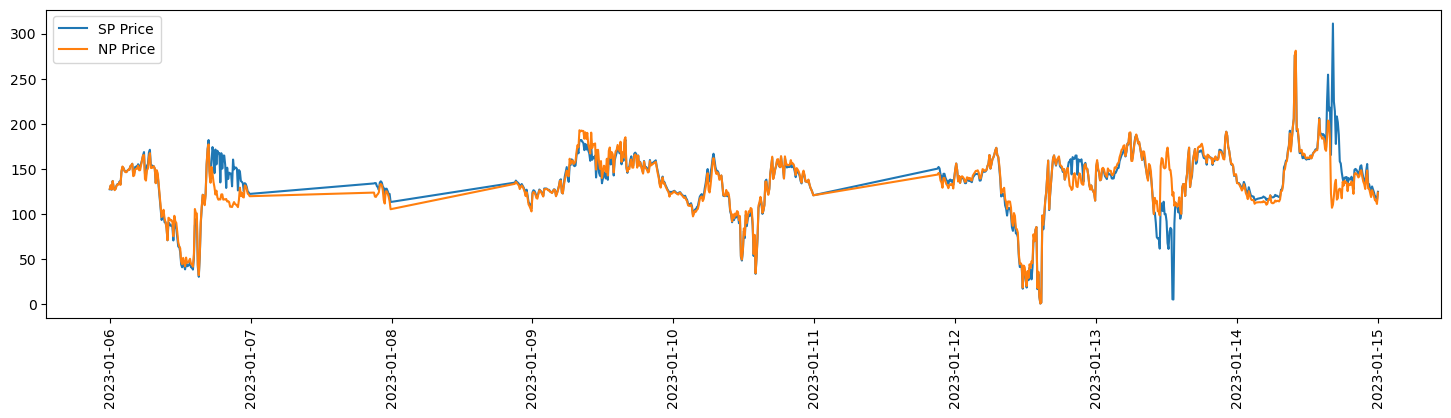

In [ ]:
time1 = datetime.datetime(2023, 1, 6, 0, 0, 0)
time2 = datetime.datetime(2023, 1, 15, 0, 0, 0)

filtered_data = pricedata[filter_times(pricedata, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['SP-15 LMP'] , label='SP Price')
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP'] , label='NP Price')
#plt.plot(filtered_data['begin_time'], filtered_data['Natural Gas Generation (MW)'] , label='Natural Gas Generation (MW)')
#plt.plot(filtered_data['begin_time'], filtered_data['Total Generation (MW)'] , label='Total Generation (MW)')
#plt.plot(np_pricedata[filter_times(np_pricedata, time1, time2)]['begin_time'], np_pricedata[filter_times(np_pricedata, time1, time2)]['NP-15 LMP'])

plt.xticks(rotation=90)
plt.legend()
plt.show()

In [ ]:
# DHI, DNI and GHI are different kinds of radiation
riverside_sunshine_data[['begin_time', 'DNI']][riverside_sunshine_data.apply(lambda x: x['DNI']>0, axis=1)]

,begin_time,DNI
188,2023-01-02 07:20:00,1
189,2023-01-02 07:30:00,1
190,2023-01-02 07:40:00,2
191,2023-01-02 07:50:00,2
192,2023-01-02 08:00:00,3
...,...,...
52505,2023-12-31 14:50:00,2
52506,2023-12-31 15:00:00,6
52507,2023-12-31 15:10:00,1
52508,2023-12-31 15:20:00,1


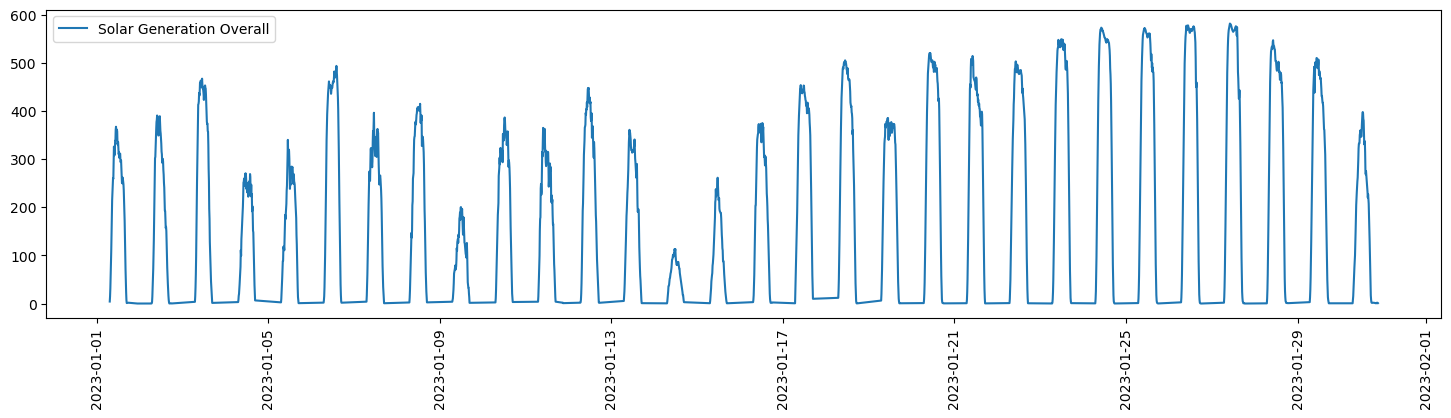

In [ ]:
time1 = datetime.datetime(2023, 1, 1, 0, 0, 0)
time2 = datetime.datetime(2023, 1, 31, 0, 0, 0)

plt.figure(figsize=(18, 4))
plt.plot(gendata[filter_times(gendata, time1, time2)]['begin_time'], gendata[filter_times(gendata, time1, time2)]['solar_scaled'], label='Solar Generation Overall')
#plt.plot(pricedata[filter_times(pricedata, time1, time2)]['begin_time'], pricedata[filter_times(pricedata, time1, time2)]['NP-15 LMP'])
#plt.plot(riverside_sunshine_data[filter_times(riverside_sunshine_data, time1, time2)]['begin_time'], riverside_sunshine_data[filter_times(riverside_sunshine_data, time1, time2)]['Clearsky DHI'], label='Riverside DHI')
#plt.plot(riverside_sunshine_data[filter_times(riverside_sunshine_data, time1, time2)]['begin_time'], riverside_sunshine_data[filter_times(riverside_sunshine_data, time1, time2)]['DNI'], label='Riverside DNI')
#plt.plot(riverside_sunshine_data[filter_times(riverside_sunshine_data, time1, time2)]['begin_time'], riverside_sunshine_data[filter_times(riverside_sunshine_data, time1, time2)]['Clearsky GHI'], label='Riverside GHI')
#plt.plot(kings_sunshine_data[filter_times(kings_sunshine_data, time1, time2)]['begin_time'], kings_sunshine_data[filter_times(kings_sunshine_data, time1, time2)]['DNI'], label='Kings DNI')
#plt.plot(kings_sunshine_data[filter_times(kings_sunshine_data, time1, time2)]['begin_time'], kings_sunshine_data[filter_times(kings_sunshine_data, time1, time2)]['Clearsky DNI'], label='Clearsky Kings DNI')

plt.xticks(rotation=90)
plt.legend()
plt.show()

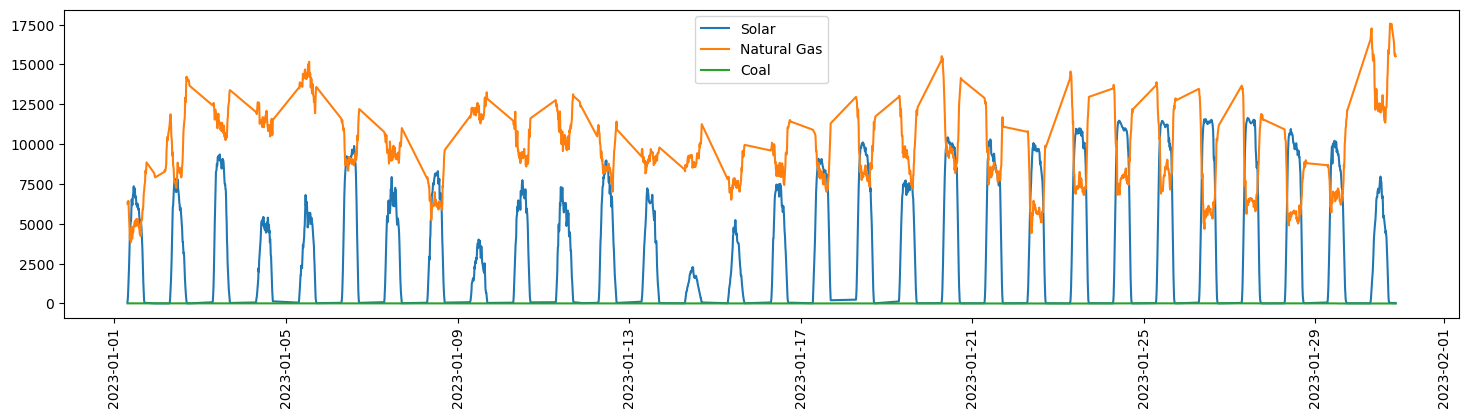

In [ ]:
plt.figure(figsize=(18, 4))
plt.plot(gendata[filter_times(gendata, time1, time2)]['begin_time'], gendata[filter_times(gendata, time1, time2)]['Solar Generation (MW)'], label='Solar')
plt.plot(gendata[filter_times(gendata, time1, time2)]['begin_time'], gendata[filter_times(gendata, time1, time2)]['Natural Gas Generation (MW)'], label='Natural Gas')
plt.plot(gendata[filter_times(gendata, time1, time2)]['begin_time'], gendata[filter_times(gendata, time1, time2)]['Coal Generation (MW)'], label='Coal')


plt.xticks(rotation=90)
plt.legend()
plt.show()